# Customer Value Modeling

## Business Problem
Businesses need to understand which customers generate the highest value so they can improve retention, prioritize support, and design better marketing strategies.

## Objective
The goal of this project is to build a regression model that estimates customer value using financial and behavioral customer features. The final output is a normalized value score between 0 and 1 that can support decision-making.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("modeled_churn_data.csv")

## Feature Relationship with Target

To understand which variables are most related to customer value, we examine the correlation between numeric features and the target variable: **Total Charges**.

This helps identify the strongest predictors before training the models.

In [2]:
df.corr(numeric_only=True)["Total Charges"].sort_values(ascending=False)

Total Charges                               1.000000
monthly_x_tenure                            0.999557
engagement_score                            0.943651
avg_monthly_value                           0.763139
revenue_per_month                           0.649869
Monthly Charges                             0.649869
cluster                                     0.451544
has_internet                                0.372454
Internet Service_Fiber optic                0.360334
Contract_Two year                           0.356080
Partner                                     0.315131
Payment Method_Bank transfer (automatic)    0.184048
Payment Method_Credit card (automatic)      0.180214
Contract_One year                           0.168133
Paperless Billing                           0.157360
Phone Service                               0.114929
service_count                               0.114929
Senior Citizen                              0.100972
Dependents                                  0.

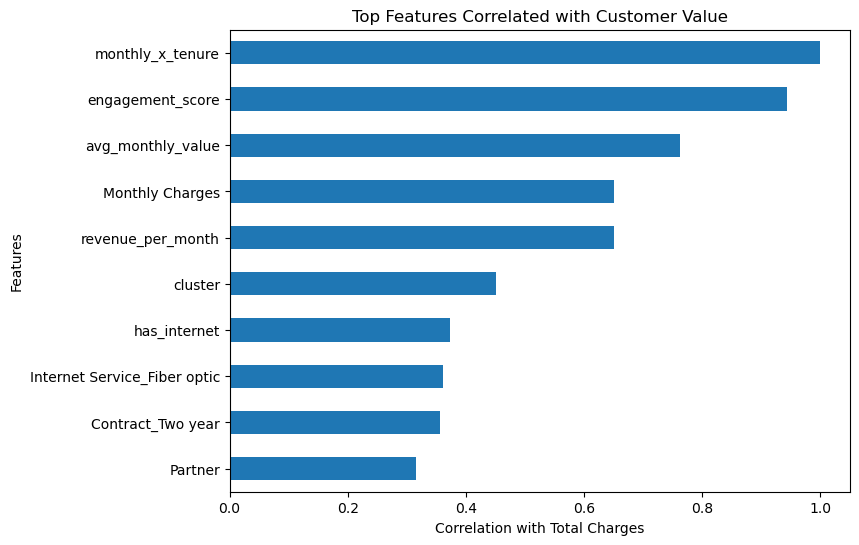

In [3]:
target_corr = df.corr(numeric_only=True)["Total Charges"].sort_values(ascending=False)

plt.figure(figsize=(8, 6))
target_corr.drop("Total Charges").head(10).sort_values().plot(kind="barh")
plt.title("Top Features Correlated with Customer Value")
plt.xlabel("Correlation with Total Charges")
plt.ylabel("Features")
plt.show()

### Key Insights

- Customer value is primarily driven by **tenure and spending behavior**, with long-term, high-paying customers contributing the most.

- **Engaged customers generate higher value**, indicating that usage and activity are strong indicators of revenue potential.

- Customers with **higher monthly charges** consistently show higher total value accumulation.

- **Advanced service users** (e.g., internet/fiber) tend to be more valuable than basic-service customers.

- **Long-term contracts** are associated with higher customer value, likely due to improved retention.

- Customer segments show clear differences in value, confirming that **behavior-based segmentation is meaningful**.

## Defining the Target and Input Features

In this project, **Total Charges** is used as the target variable because it reflects the monetary value generated by each customer.

We remove variables such as churn labels, cluster assignments, and churn prediction outputs because they may introduce data leakage or represent downstream modeling outputs rather than original customer attributes.

In [4]:
y = df["Total Charges"]

In [5]:
X = df.drop([
    "Total Charges",
    "Churn",
    "cluster",
    "segment",
    "churn_probability",
    "churn_prediction",
    'monthly_x_tenure',   
    'avg_monthly_value',  
    'revenue_per_month',  
    'engagement_score' 
], axis=1)

In [6]:
X = pd.get_dummies(X, drop_first=True)

## Train-Test Split and Feature Preparation

The dataset is split into training and testing sets so model performance can be evaluated on unseen data.

Additional preprocessing is then applied to:
- keep numeric features,
- identify binary Yes/No columns,
- convert them into numeric values,
- and ensure consistent model-ready input.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Feature Encoding

Machine learning models require numeric inputs, so categorical features are transformed into a numeric format using one-hot encoding.

This ensures that customer attributes can be used effectively during training.

In [8]:
cat_cols = X_train.select_dtypes(include='object').columns
num_cols = X_train.select_dtypes(include=np.number).columns


yes_no_cols = []
for col in cat_cols:
    vals = set(X_train[col].dropna().unique())
    if vals <= {'Yes', 'No'}:
        yes_no_cols.append(col)


X_train = X_train[num_cols.tolist() + yes_no_cols].copy()
X_test = X_test[num_cols.tolist() + yes_no_cols].copy()


In [9]:
for col in yes_no_cols:
    X_train[col] = X_train[col].replace({'Yes': 1, 'No': 0})
    X_test[col] = X_test[col].replace({'Yes': 1, 'No': 0})


print("Remaining object columns:")
print(X_train.select_dtypes(include='object').columns)

X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')

leakage_cols = [
   
]


X_train = X_train.drop(columns=leakage_cols)
X_test = X_test.drop(columns=leakage_cols)

Remaining object columns:
Index([], dtype='object')


## Model Training

Three regression models are trained and compared:

- **Linear Regression** as a simple baseline
- **Random Forest Regressor** for non-linear relationships
- **XGBoost Regressor** for stronger predictive performance

This comparison helps identify the best model for estimating customer value.

In [10]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [11]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [12]:
xgb = XGBRegressor()
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

## Model Evaluation

The models are evaluated using:

- **MAE**: average prediction error
- **RMSE**: larger errors are penalized more heavily
- **R²**: proportion of variance explained by the model

The best-performing model will be selected for customer scoring.

In [13]:
models = {
    "Linear": lr,
    "Random Forest": rf,
    "XGBoost": xgb
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    
    print(f"\n{name}")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))
    print("R2:", r2_score(y_test, y_pred))


Linear
MAE: 897.0025292760146
RMSE: 1073.008102493146
R2: 0.7860483276253103

Random Forest
MAE: 522.8835883404863
RMSE: 824.814727375927
R2: 0.8735780466423039

XGBoost
MAE: 538.9313969837237
RMSE: 844.4997759709535
R2: 0.8674716594204653


C:\Users\Hussein\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\Hussein\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\Hussein\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## Evaluation Insight

Among the tested models, **XGBoost** achieved the strongest predictive performance, making it the best choice for estimating customer value.

Its results suggest that customer value is influenced by non-linear interactions between features, which tree-based ensemble methods are better able to capture than simple linear models.

C:\Users\Hussein\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\Hussein\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\Hussein\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


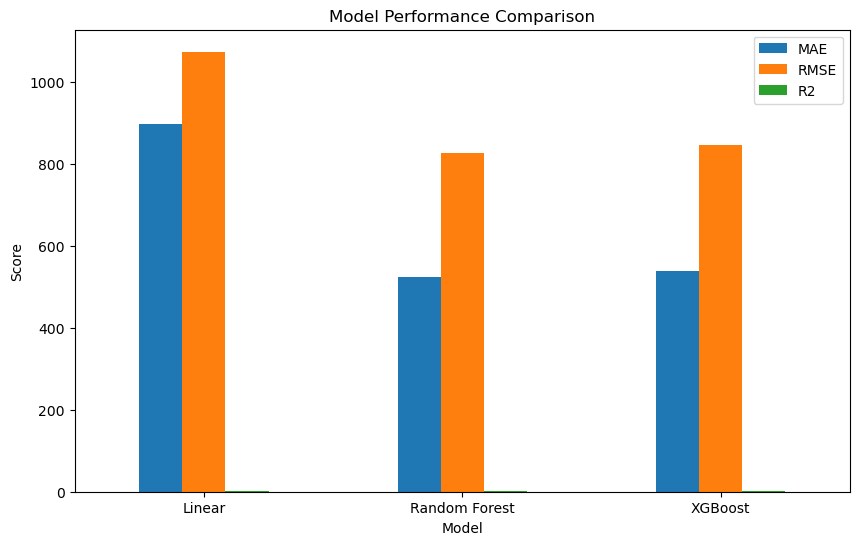

In [14]:
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": mean_squared_error(y_test, y_pred, squared=False),
        "R2": r2_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df

results_df.set_index("Model")[["MAE", "RMSE", "R2"]].plot(
    kind="bar",
    figsize=(10, 6)
)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

### Key Insights

Random Forest and XGBoost outperform Linear Regression, showing that customer value is driven by complex, non-linear patterns. Random Forest achieves the lowest prediction error, making it the most reliable model, while XGBoost delivers similarly strong performance. Linear Regression performs weakest, highlighting the limitations of simple models for this problem.

## Production-Style Feature Preparation

To apply the model consistently to the full dataset, a reusable feature preparation function is created.

This step ensures that the same preprocessing logic used during training is also used during scoring, which is essential for reliable deployment.

In [15]:
def prepare_features(data, num_cols, yes_no_cols, leakage_cols, train_columns=None):
    X_prep = data[num_cols.tolist() + yes_no_cols].copy()
    
    for col in yes_no_cols:
        X_prep[col] = X_prep[col].replace({'Yes': 1, 'No': 0})
    
    X_prep = X_prep.apply(pd.to_numeric, errors='coerce')
    X_prep = X_prep.drop(columns=leakage_cols)
    
    if train_columns is not None:
        X_prep = X_prep.reindex(columns=train_columns, fill_value=0)
    
    return X_prep

## Customer Value Prediction

The selected model is now applied to the full dataset to estimate the predicted value of each customer.

This creates a model-based customer value estimate that can be used for ranking and segmentation.

In [16]:
best_model = xgb  

X_full = prepare_features(X, num_cols, yes_no_cols, leakage_cols, X_train.columns)
df["predicted_value"] = best_model.predict(X_full)

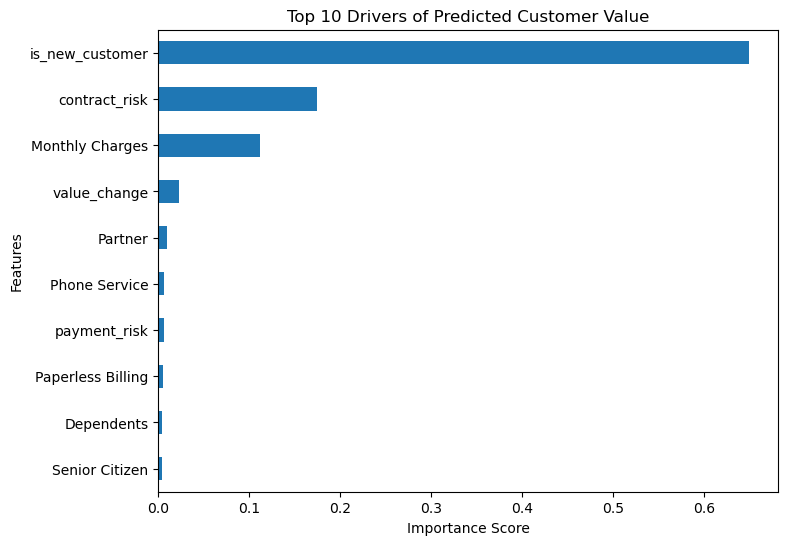

In [17]:
feature_importance = pd.Series(xgb.feature_importances_, index=X_train.columns)
top_features = feature_importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 6))
top_features.sort_values().plot(kind="barh")
plt.title("Top 10 Drivers of Predicted Customer Value")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

## Creating a Normalized Value Score

Predicted customer values are normalized into a **value score between 0 and 1**.

This makes the output easier to interpret and compare across customers, where:
- values closer to **1** indicate higher-value customers
- values closer to **0** indicate lower-value customers

In [18]:
df["value_score"] = (
    df["predicted_value"] - df["predicted_value"].min()
) / (
    df["predicted_value"].max() - df["predicted_value"].min()
)

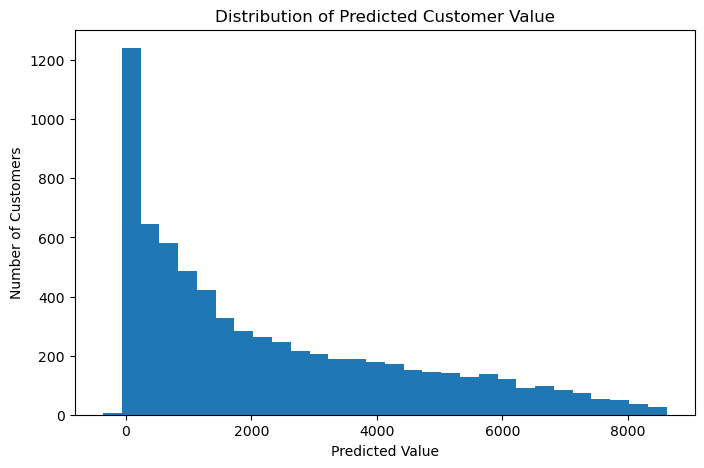

In [19]:
plt.figure(figsize=(8, 5))
plt.hist(df["predicted_value"], bins=30)
plt.title("Distribution of Predicted Customer Value")
plt.xlabel("Predicted Value")
plt.ylabel("Number of Customers")
plt.show()

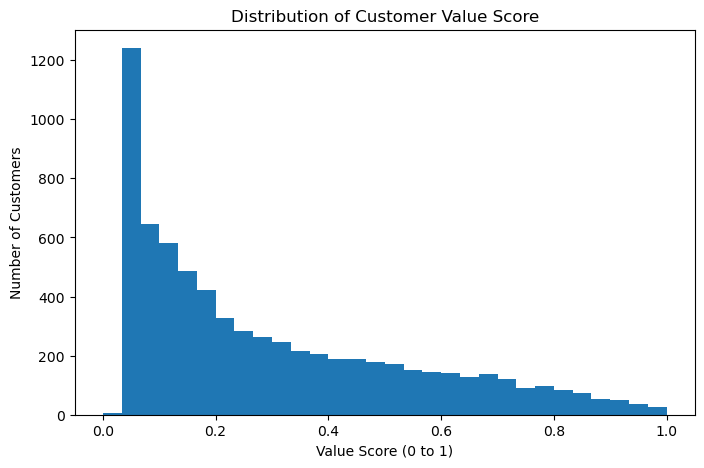

In [20]:
plt.figure(figsize=(8, 5))
plt.hist(df["value_score"], bins=30)
plt.title("Distribution of Customer Value Score")
plt.xlabel("Value Score (0 to 1)")
plt.ylabel("Number of Customers")
plt.show()

In [21]:
df["value_segment"] = pd.cut(
    df["value_score"],
    bins=[0, 0.33, 0.66, 1],
    labels=["Low Value", "Medium Value", "High Value"],
    include_lowest=True
)

df["value_segment"].value_counts()

value_segment
Low Value       4479
Medium Value    1710
High Value       801
Name: count, dtype: int64

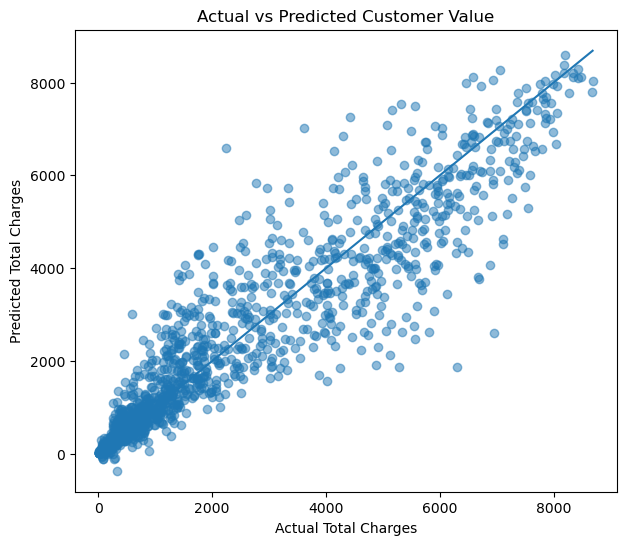

In [22]:
y_pred_xgb = xgb.predict(X_test)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Actual vs Predicted Customer Value")
plt.xlabel("Actual Total Charges")
plt.ylabel("Predicted Total Charges")
plt.show()

### Key Insights

The model shows strong predictive performance, with predictions aligning closely along the diagonal. Accuracy is highest for low to mid-value customers, while variability increases for high-value customers, indicating slightly higher error in extreme cases. Overall, the model captures the general trend well, with only a few outliers.

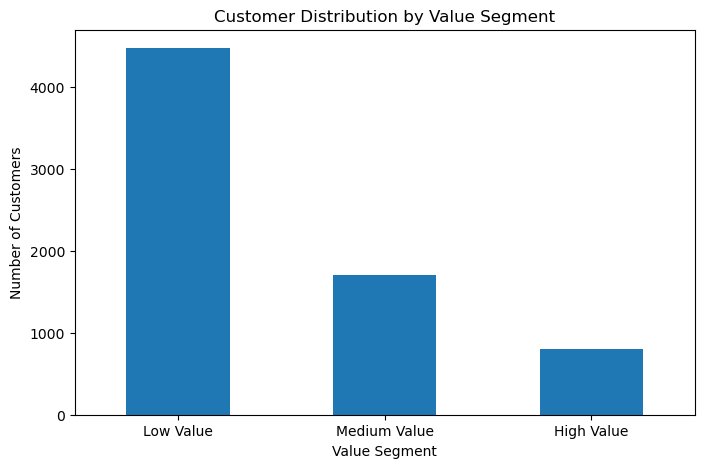

In [23]:
df["value_segment"].value_counts().plot(kind="bar", figsize=(8, 5))
plt.title("Customer Distribution by Value Segment")
plt.xlabel("Value Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

### Key Insights

Most customers are concentrated in the low-value segment, while high-value customers form a small but highly important group. This indicates that a limited number of customers likely generate a large share of revenue, making them key targets for retention and value-focused strategies.

## Exporting the Final Scored Dataset

The final dataset is exported with predicted customer value and normalized value score.

This output can be used in dashboards, retention systems, segmentation workflows, or decision support tools.

In [24]:
df.to_csv("final_scored_data.csv", index=False)

## Final Conclusion

This project developed a customer value modeling pipeline to estimate the historical value of each customer based on financial and service-related behavior.

After comparing Linear Regression, Random Forest, and XGBoost, **XGBoost** delivered the strongest predictive performance and was selected as the final model. The predicted values were then normalized into a **value score** and grouped into customer value segments for easier business interpretation.

These results can support actions such as:
- prioritizing high-value customer retention,
- identifying medium-value customers with upsell potential,
- and improving customer targeting through value-based segmentation.